<a href="https://colab.research.google.com/github/Akanksha2622/Electricity-Consumption-EDA/blob/main/electricity_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [4]:
df = pd.read_csv(
    '/content/drive/My Drive/Data analyst/household_power_consumption.txt',
    sep=';',
    parse_dates={'DateTime': ['Date', 'Time']},
    na_values=['?'],
    low_memory=False
)

df.set_index('DateTime', inplace=True)

print(f"Dataset size: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()

Dataset size: 2,075,259 rows × 7 columns
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
df_clean = df.dropna()
df_clean['Global_active_power'] = pd.to_numeric(df_clean['Global_active_power'])

df_clean['Year']      = df_clean.index.year
df_clean['Month']     = df_clean.index.month
df_clean['Hour']      = df_clean.index.hour
df_clean['DayOfWeek'] = df_clean.index.dayofweek
df_clean['IsWeekend'] = df_clean['DayOfWeek'] >= 5

print(f"Rows after cleaning: {df_clean.shape[0]:,}")
print("✅ Data cleaned and ready!")

Rows after cleaning: 2,049,280
✅ Data cleaned and ready!


In [6]:
stats = df_clean['Global_active_power'].describe()
print("=== Electricity Consumption Summary ===")
print(f"Average power used:  {stats['mean']:.3f} kW")
print(f"Maximum power used:  {stats['max']:.3f} kW")
print(f"Minimum power used:  {stats['min']:.3f} kW")

daily_avg   = df_clean['Global_active_power'].resample('D').mean()
monthly_avg = df_clean['Global_active_power'].resample('ME').mean()

print(f"\nHighest daily average: {daily_avg.max():.3f} kW")
print(f"Lowest daily average:  {daily_avg.min():.3f} kW")
print("\n✅ Statistics done!")

=== Electricity Consumption Summary ===
Average power used:  1.092 kW
Maximum power used:  11.122 kW
Minimum power used:  0.076 kW

Highest daily average: 3.315 kW
Lowest daily average:  0.174 kW

✅ Statistics done!


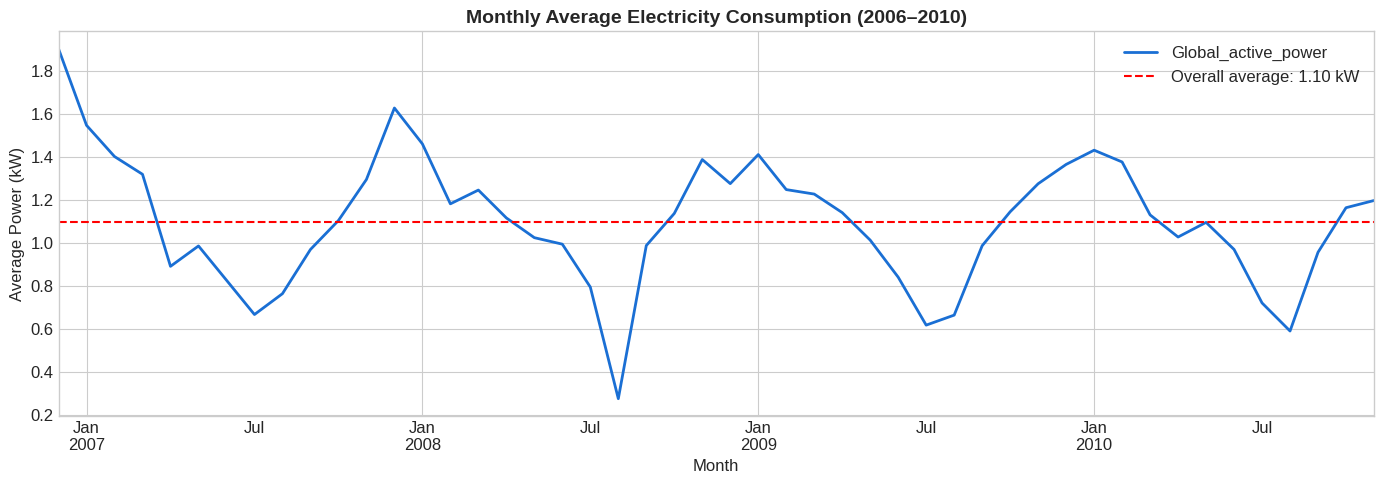

📊 Chart 1 done!


In [7]:
plt.figure(figsize=(14, 5))
monthly_avg.plot(color='#1a6fd4', linewidth=2)
plt.title('Monthly Average Electricity Consumption (2006–2010)',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Power (kW)')
plt.axhline(y=monthly_avg.mean(), color='red', linestyle='--',
            label=f'Overall average: {monthly_avg.mean():.2f} kW')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Data analyst/chart1_monthly_trend.png', dpi=150)
plt.show()
print("📊 Chart 1 done!")

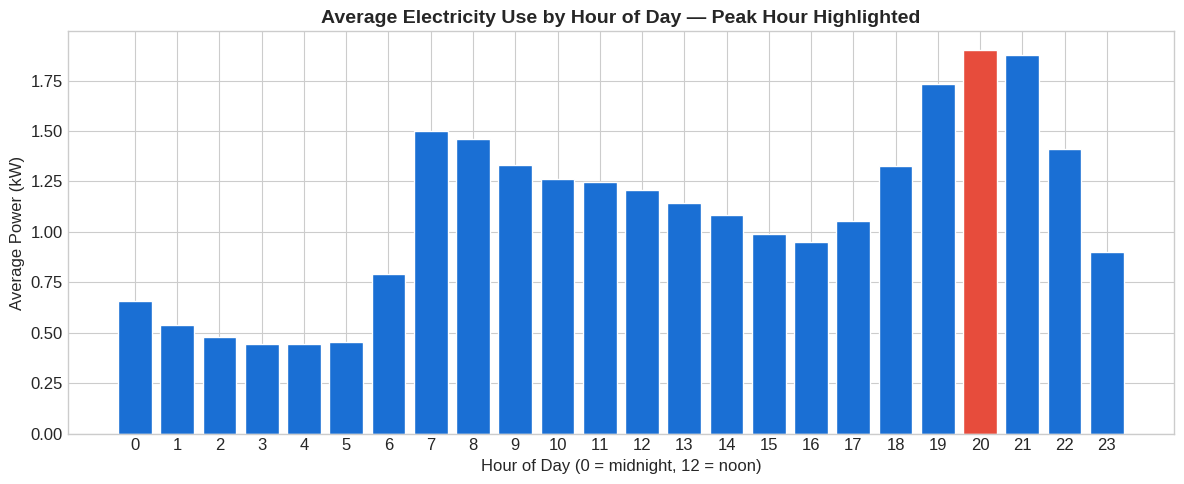

⚡ Peak hour: 20:00 with 1.899 kW average


In [8]:
hourly_avg = df_clean.groupby('Hour')['Global_active_power'].mean()

colors = ['#e74c3c' if x == hourly_avg.idxmax()
          else '#1a6fd4' for x in hourly_avg.index]

plt.figure(figsize=(12, 5))
plt.bar(hourly_avg.index, hourly_avg.values, color=colors, edgecolor='white')
plt.title('Average Electricity Use by Hour of Day — Peak Hour Highlighted',
          fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0 = midnight, 12 = noon)')
plt.ylabel('Average Power (kW)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Data analyst/chart2_peak_hours.png', dpi=150)
plt.show()
print(f"⚡ Peak hour: {hourly_avg.idxmax()}:00 with {hourly_avg.max():.3f} kW average")

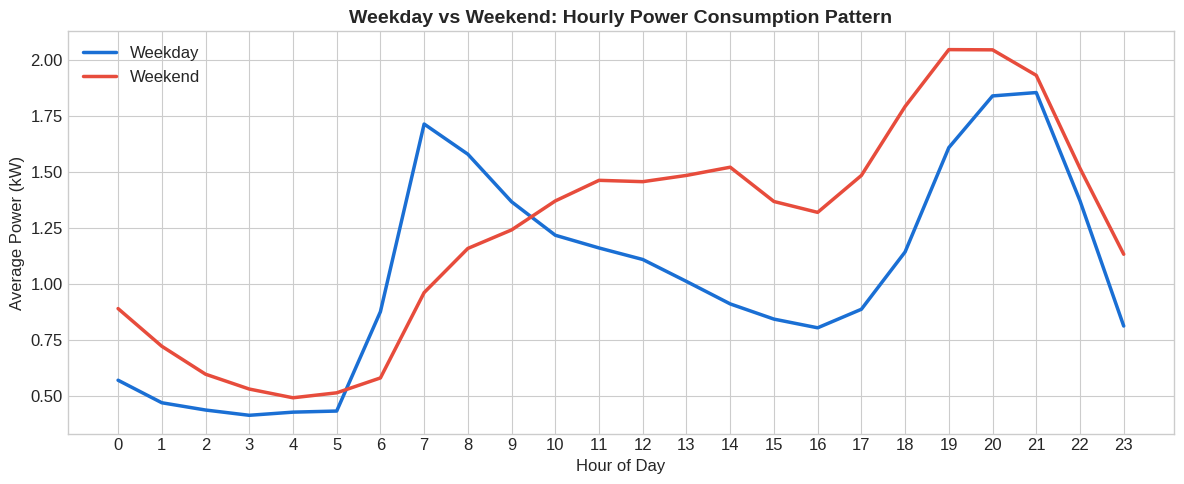

✅ Chart 3 done!


In [9]:
weekend = df_clean[df_clean['IsWeekend']].groupby('Hour')['Global_active_power'].mean()
weekday = df_clean[~df_clean['IsWeekend']].groupby('Hour')['Global_active_power'].mean()

plt.figure(figsize=(12, 5))
plt.plot(weekday.index, weekday.values, label='Weekday',
         color='#1a6fd4', linewidth=2.5)
plt.plot(weekend.index, weekend.values, label='Weekend',
         color='#e74c3c', linewidth=2.5)
plt.title('Weekday vs Weekend: Hourly Power Consumption Pattern',
          fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average Power (kW)')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Data analyst/chart3_weekday_weekend.png', dpi=150)
plt.show()
print("✅ Chart 3 done!")

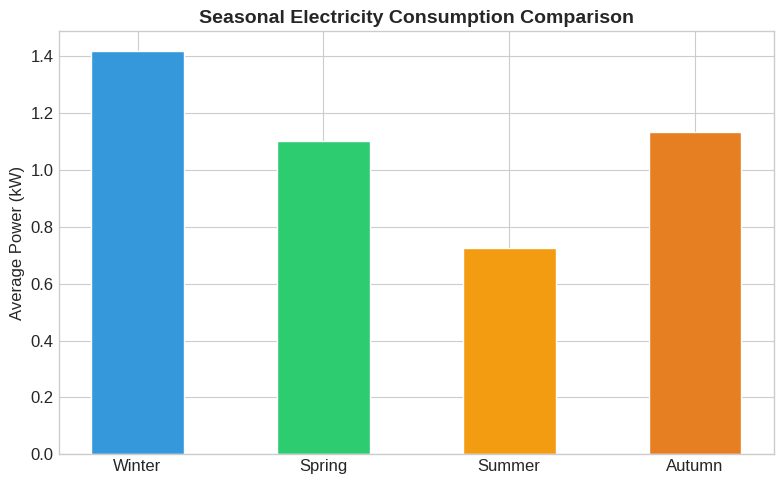

❄️ Highest: Winter | ☀️ Lowest: Summer


In [10]:
def get_season(month):
    if month in [12, 1, 2]:   return 'Winter'
    elif month in [3, 4, 5]:  return 'Spring'
    elif month in [6, 7, 8]:  return 'Summer'
    else:                      return 'Autumn'

df_clean['Season'] = df_clean['Month'].apply(get_season)
season_avg = df_clean.groupby('Season')['Global_active_power'].mean()
season_order  = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = ['#3498db', '#2ecc71', '#f39c12', '#e67e22']

plt.figure(figsize=(8, 5))
plt.bar(season_order,
        [season_avg[s] for s in season_order],
        color=season_colors, edgecolor='white', width=0.5)
plt.title('Seasonal Electricity Consumption Comparison',
          fontsize=14, fontweight='bold')
plt.ylabel('Average Power (kW)')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Data analyst/chart4_seasonal.png', dpi=150)
plt.show()
print(f"❄️ Highest: {season_avg.idxmax()} | ☀️ Lowest: {season_avg.idxmin()}")

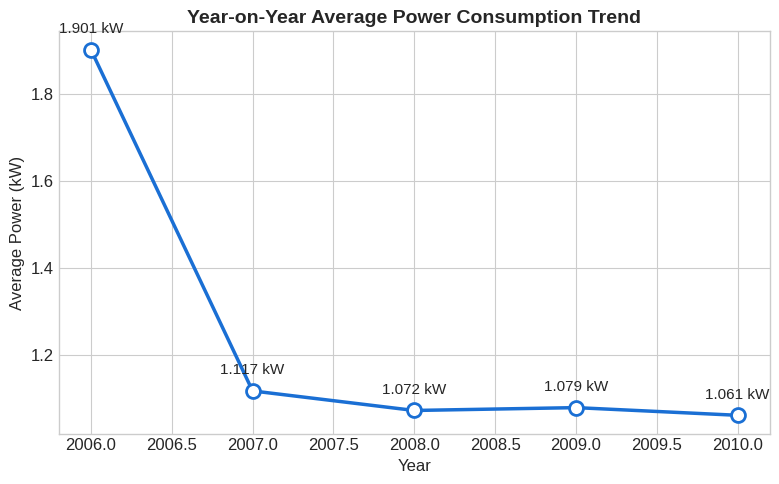

✅ Chart 5 done!


In [11]:
yearly_avg = df_clean.groupby('Year')['Global_active_power'].mean()

plt.figure(figsize=(8, 5))
plt.plot(yearly_avg.index, yearly_avg.values,
         marker='o', markersize=10, color='#1a6fd4',
         linewidth=2.5, markerfacecolor='white', markeredgewidth=2)

for year, val in yearly_avg.items():
    plt.annotate(f'{val:.3f} kW', (year, val),
                 textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=11)

plt.title('Year-on-Year Average Power Consumption Trend',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Power (kW)')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Data analyst/chart5_yearly.png', dpi=150)
plt.show()
print("✅ Chart 5 done!")

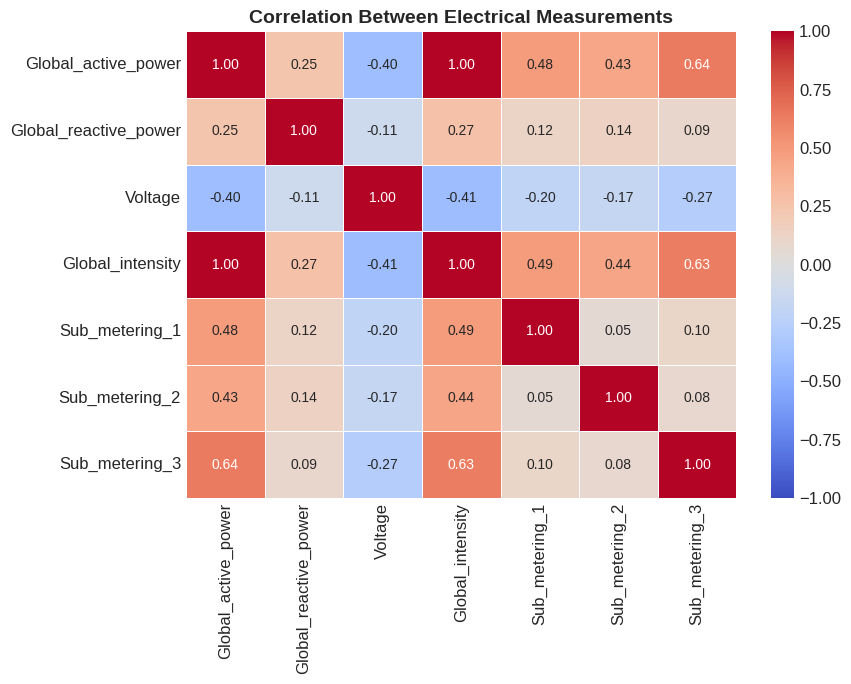

✅ ALL 6 CHARTS DONE! 🎉


In [12]:
cols = ['Global_active_power', 'Global_reactive_power',
        'Voltage', 'Global_intensity',
        'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

corr_matrix = df_clean[cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Correlation Between Electrical Measurements',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Data analyst/chart6_correlation.png', dpi=150)
plt.show()
print("✅ ALL 6 CHARTS DONE! 🎉")